# Logistic Regression from Scratch
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Implementing Logistic Regression with sigmoid, log-loss, and gradient descent from scratch, compared against scikit-learn.

Main goals:

- Implement the sigmoid function and log-loss cost.
- Build a LogisticRegression class with gradient descent.
- Evaluate with a confusion matrix.
- Compare against `sklearn.linear_model.LogisticRegression`.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Sigmoid Function

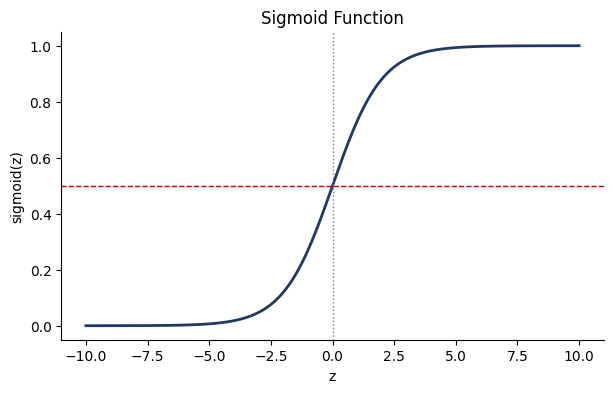

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), color='#1F3864', lw=2)
ax.axhline(0.5, color='#C00000', linestyle='--', lw=1)
ax.axvline(0, color='gray', linestyle=':', lw=1)
ax.set_xlabel('z')
ax.set_ylabel('sigmoid(z)')
ax.set_title('Sigmoid Function')
plt.show()

## Log-Loss

In [3]:
def log_loss(y_true, y_pred_proba, eps=1e-12):
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

print('Loss when prediction matches label (0.95 for true label 1):', round(log_loss(np.array([1]), np.array([0.95])), 4))
print('Loss when prediction is wrong (0.05 for true label 1):     ', round(log_loss(np.array([1]), np.array([0.05])), 4))

Loss when prediction matches label (0.95 for true label 1): 0.0513
Loss when prediction is wrong (0.05 for true label 1):      2.9957


**Observation:**
Loss stays small for a confident correct prediction and grows sharply for a confident wrong one — log-loss penalises confident mistakes much more than uncertain ones.

## Dataset

In [4]:
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}')

Train: (320, 2)  Test: (80, 2)


## LogisticRegression Class

In [5]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=2000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)

        for _ in range(self.n_iterations):
            z = X @ self.w + self.b
            y_pred = sigmoid(z)
            self.cost_history.append(log_loss(y, y_pred))

            dw = (1/m) * (X.T @ (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [6]:
model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)
print(f'Test accuracy: {accuracy_score(y_test, preds):.4f}')

Test accuracy: 0.9000


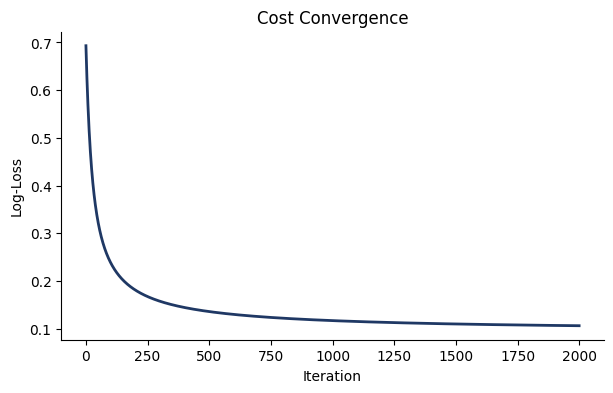

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(model.cost_history, color='#1F3864', lw=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Log-Loss')
ax.set_title('Cost Convergence')
plt.show()

## Confusion Matrix

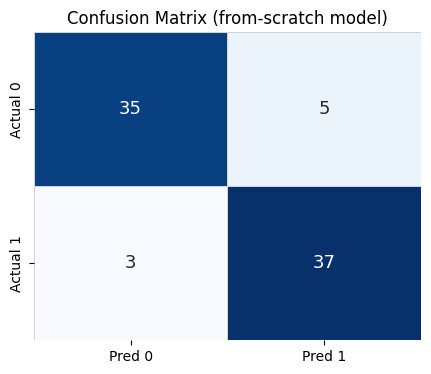

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        40
           1       0.88      0.93      0.90        40

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80



In [8]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix (from-scratch model)')
plt.show()

print(classification_report(y_test, preds))

## Comparison with sklearn

In [9]:
sk_model = LogisticRegression()
sk_model.fit(X_train_scaled, y_train)
sk_preds = sk_model.predict(X_test_scaled)

print(f'Scratch accuracy:  {accuracy_score(y_test, preds):.4f}')
print(f'sklearn accuracy:  {accuracy_score(y_test, sk_preds):.4f}')
print(f'\nScratch weights: {model.w.round(4)}, bias: {round(model.b, 4)}')
print(f'sklearn weights: {sk_model.coef_[0].round(4)}, bias: {round(sk_model.intercept_[0], 4)}')

Scratch accuracy:  0.9000
sklearn accuracy:  0.9000

Scratch weights: [1.1413 5.5519], bias: -0.8257
sklearn weights: [0.9129 4.6464], bias: -0.6482


**Observation:**
The custom implementation produces results comparable to sklearn on the same dataset used in the notebook. Small parameter differences are expected because sklearn uses a more mature solver and regularisation defaults